<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Artificial_Bee_Colony.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
NUM_CIUDADES = 20

In [3]:
#Establecemos las ubicaciones de las ciudades
ciudades=np.array([
  [10,20],[12,3],
  [1,20],[2,6],
  [5,4],[8,4],
  [5,0],[15,8],
  [1,9],[10,15],
  [11,13],[4,10],
  [7,20],[3,3],
  [5,9],[9,18],
  [4,16],[9,11],
  [2,1],[15,15]])

In [5]:
# MATRIZ DE DISTANCIAS

distancias = np.zeros(
    (NUM_CIUDADES, NUM_CIUDADES)
)

for i in range(NUM_CIUDADES):
    for j in range(NUM_CIUDADES):

        if i != j:
            x1, y1 = ciudades[i]
            x2, y2 = ciudades[j]

            distancias[i][j] = np.sqrt(
                (x1-x2)**2 +
                (y1-y2)**2
            )

In [6]:
# PARÁMETROS ABC

NUM_ABEJAS = 50
ITERACIONES = 300
LIMITE = 30

In [7]:
# DISTANCIA DE UNA RUTA
def distancia_total(ruta):

    total = 0

    for i in range(NUM_CIUDADES-1):
        total += distancias[
            ruta[i]
        ][
            ruta[i+1]
        ]

    total += distancias[
        ruta[-1]
    ][
        ruta[0]
    ]

    return total

In [8]:
# FUNCIÓN FITNESS
def fitness(ruta):
    return 1 / (1 + distancia_total(ruta))

In [9]:
# GENERAR SOLUCIÓN ALEATORIA

def nueva_ruta():
    ruta = list(range(NUM_CIUDADES))
    random.shuffle(ruta)
    return ruta

In [10]:
# VECINO (SWAP)

def vecino(ruta):

    nueva = ruta.copy()

    i, j = random.sample(
        range(NUM_CIUDADES),
        2
    )

    nueva[i], nueva[j] = (
        nueva[j],
        nueva[i]
    )

    return nueva


In [11]:
# INICIALIZACIÓN

poblacion = [
    nueva_ruta()
    for _ in range(NUM_ABEJAS)
]

intentos = [0] * NUM_ABEJAS

mejor_ruta = None
mejor_distancia = float('inf')

In [16]:
# ABC
distancia_historial = [] # Initialize the history list

for it in range(ITERACIONES):

    # ABEJAS EMPLEADAS

    for i in range(NUM_ABEJAS):

        candidata = vecino(
            poblacion[i]
        )

        if fitness(candidata) > fitness(
                poblacion[i]):

            poblacion[i] = candidata
            intentos[i] = 0

        else:
            intentos[i] += 1


    # PROBABILIDADES
    fitnesses = np.array(
        [fitness(r)
         for r in poblacion]
    )

    probabilidades = (
        fitnesses /
        fitnesses.sum()
    )


    # ABEJAS OBSERVADORAS
    for _ in range(NUM_ABEJAS):

        i = np.random.choice(
            range(NUM_ABEJAS),
            p=probabilidades
        )

        candidata = vecino(
            poblacion[i]
        )

        if fitness(candidata) > fitness(
                poblacion[i]):

            poblacion[i] = candidata
            intentos[i] = 0

        else:
            intentos[i] += 1


    # ABEJAS EXPLORADORAS
    for i in range(NUM_ABEJAS):

        if intentos[i] > LIMITE:

            poblacion[i] = nueva_ruta()
            intentos[i] = 0


    # MEJOR SOLUCIÓN
    for ruta in poblacion:

        d = distancia_total(ruta)

        if d < mejor_distancia:
            mejor_distancia = d
            mejor_ruta = ruta.copy()

    distancia_historial.append(mejor_distancia) # Store the best distance for this iteration
    if (it+1) % 20 == 0:
        print(
            f"Iteración {it+1:3d}"
            f"  Mejor distancia:"
            f" {mejor_distancia:.2f}"
        )

Iteración  20  Mejor distancia: 88.32
Iteración  40  Mejor distancia: 88.32
Iteración  60  Mejor distancia: 88.32
Iteración  80  Mejor distancia: 85.97
Iteración 100  Mejor distancia: 78.83
Iteración 120  Mejor distancia: 78.59
Iteración 140  Mejor distancia: 78.59
Iteración 160  Mejor distancia: 78.59
Iteración 180  Mejor distancia: 78.59
Iteración 200  Mejor distancia: 78.59
Iteración 220  Mejor distancia: 78.59
Iteración 240  Mejor distancia: 78.59
Iteración 260  Mejor distancia: 78.59
Iteración 280  Mejor distancia: 78.59
Iteración 300  Mejor distancia: 78.59


In [17]:
# RESULTADOS

print("\nMejor ruta:")
print(mejor_ruta)

print(
    "Distancia:",
    round(mejor_distancia, 2)
)


Mejor ruta:
[15, 0, 12, 2, 16, 11, 14, 8, 3, 4, 13, 18, 6, 5, 1, 7, 19, 10, 17, 9]
Distancia: 78.59


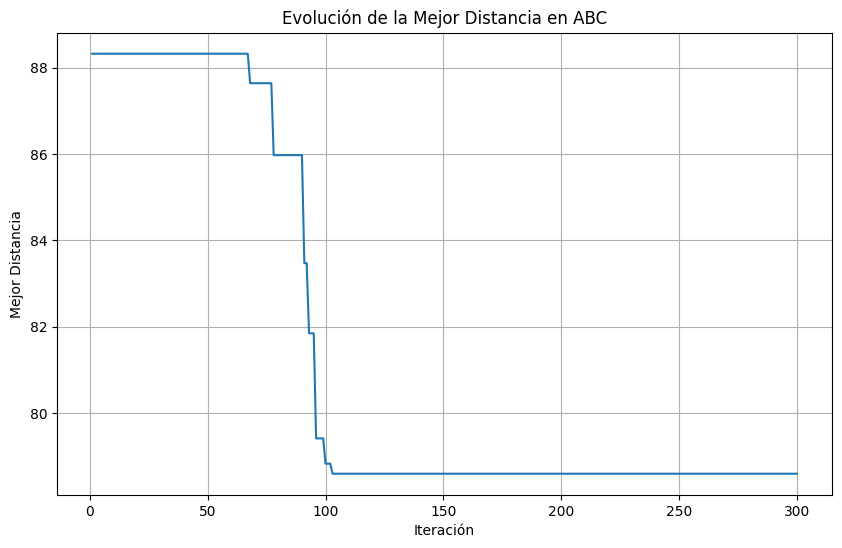

In [19]:
if 'distancia_historial' in locals() and len(distancia_historial) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(distancia_historial) + 1), distancia_historial)
    plt.title('Evolución de la Mejor Distancia en ABC')
    plt.xlabel('Iteración')
    plt.ylabel('Mejor Distancia')
    plt.grid(True)
    plt.show()
else:
    print("El historial de distancias no está disponible. Asegúrate de ejecutar el algoritmo ACO (celda HsVgC-p2SXNN) primero para recopilar los datos.")

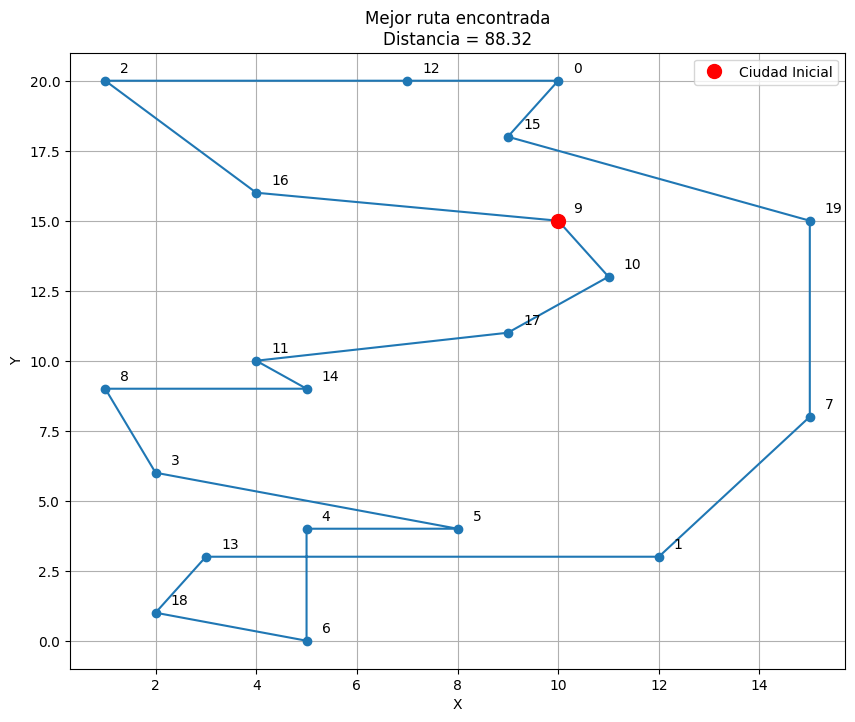

In [15]:
# GRAFICAR RUTA

ruta = mejor_ruta + [mejor_ruta[0]]

x = [ciudades[i][0] for i in ruta]
y = [ciudades[i][1] for i in ruta]

plt.figure(figsize=(10, 8))
plt.plot(x,y,'-o')

# Poner en rojo la ciudad inicial
start_city_index = mejor_ruta[0]
start_x = ciudades[start_city_index][0]
start_y = ciudades[start_city_index][1]
plt.plot(start_x, start_y, 'o', color='red',
         markersize=10, label='Ciudad Inicial')

for i, (cx, cy) in enumerate(ciudades):
    plt.text(cx + 0.3,cy + 0.3,str(i))

plt.title(
    f'Mejor ruta encontrada\n'
    f'Distancia = {mejor_distancia:.2f}'
)

plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)
plt.legend()
plt.show()